# 第 08c 课:训练 NequIP 与 rMD17 二番战

**你将学到**

- 用联合能量 + 力损失训练第 08b 课的 `SimpleNequIP` 架构,并分析其学习曲线和力奇偶校验图(parity plot)。
- 在训练**之后**检验等变性,确认梯度下降无法破坏内建于架构中的对称性。

- 在 rMD17 阿司匹林上让同一模型与第 07 课的 SchNet 和 DimeNet 基准同场竞技。
- 把训练好的 checkpoint 导出到 `artifacts/`,供第 11 课用它运行分子动力学模拟。

<details><summary>English</summary>

# Lesson 08c: Training NequIP and the rMD17 Rematch

**What you will learn**

- Train the `SimpleNequIP` architecture of Lesson 08b with a joint energy +
  force loss, and analyze its learning curves and force parity plot.
- Test for equivariance **after** the training to confirm that gradient descent
  cannot damage a symmetry that is built into the architecture.
- Run the same model against the Lesson 07's SchNet and DimeNet baselines on
  rMD17 aspirin.
- Export the trained checkpoint to `artifacts/` for Lesson 11 to enable running
  a molecular dynamics simulation with it.

</details>

**先修要求:**

- [第 08b 课](08b_nequip_implementation.ipynb):`SimpleNequIP` 的实现及生成的模块 `artifacts/nequip_model.py`,本课将导入它,
- [第 08a 课](08a_nequip_theory.ipynb):损失函数与 scale/shift 初始化,
- [第 07a 课](07a_schnet.ipynb)、[07b](07b_dimenet.ipynb)和
  [07c](07c_rmd17_aspirin.ipynb):SchNet、DimeNet++,以及我们在此与之比较结果的氩/阿司匹林协议。

<details><summary>English</summary>

**Prerequisites**: 

- [Lesson 08b](08b_nequip_implementation.ipynb): the `SimpleNequIP` implementation
  and the generated module, `artifacts/nequip_model.py`, which this lesson imports,
- [Lesson 08a](08a_nequip_theory.ipynb): the loss function and the scale/shift
  initialization,
- [Lesson 07a](07a_schnet.ipynb), [07b](07b_dimenet.ipynb) and
  [07c](07c_rmd17_aspirin.ipynb): SchNet, DimeNet++, and the argon/aspirin
  protocol whose results we compare against here.

</details>

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>注意:</b> 本课不重新构建架构本身。第 08b 课已将其打包为模块(<code>artifacts/nequip_model.py</code>),本课将其作为模块导入。如果 <code>nequip_model.py</code> 文件因故不在 <code>notebooks/artifacts/</code> 中,请先运行第 08b 课。
</div>

<details><summary>English</summary>

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The architecture itself is not rebuilt here. Lesson 08b packaged it
as a module (<code>artifacts/nequip_model.py</code>), and this lesson imports it
as one. Run Lesson 08b first if the <code>nequip_model.py</code> file is not in
the <code>notebooks/artifacts/</code> for any reason.
</div>

</details>

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable
sys.path.insert(0, "")      # Make ./artifacts importable

import copy
import pathlib
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.data import make_lj_argon_dataset, radius_graph, train_val_split, load_rmd17
from course_utils.plotting import plot_training_curves

# The architecture, imported from the module Lesson 08b generated
from artifacts.nequip_model import SimpleNequIP, energy_and_forces


torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
# dtype strategy: float32 (default) for training speed; equivariance checks use float64 copies.
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## 数据集与模型

在本课中,我们完全沿用第 08b 课的设置:同样的 200 帧 Lennard-Jones 氩轨迹
(`course_utils.data.make_lj_argon_dataset`,$\varepsilon = 0.0104$ eV,$\sigma = 3.4$ Å,8 个原子)、同样的确定性 150 训练 / 50 验证划分、同样的 $r_c = 6$ Å,以及同样的用于卷积归一化的平均邻居数 $\bar N$。由于生成器和划分都是有种子确定的,下面的数字与 08b 打印的一致。

<details><summary>English</summary>

## The dataset and the model

In this lesson, we reuse our previous setup in Lesson 08b exactly: the same
200-frame Lennard-Jones argon trajectory
(`course_utils.data.make_lj_argon_dataset`, $\varepsilon = 0.0104$ eV, $\sigma =
3.4$ Å, 8 atoms), the same deterministic 150 train / 50 validation split, the
same $r_c = 6$ Å, and the same average neighbor count $\bar N$ that normalizes
the convolution. Because both the generator and the split are seeded, the
numbers below match the ones 08b printed.

</details>

In [2]:
# The same data as Lesson 08b: seeded generator, seeded split
frames = make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)
train_frames, val_frames = train_val_split(frames, val_fraction=0.25, seed=0)
n_atoms = frames[0]["pos"].shape[0]
r_cut = 6.0

# Average number of neighbors over the training set: the convolution's 1/sqrt(N_bar)
avg_num_neighbors = float(np.mean(
    [radius_graph(f["pos"], r_cut).shape[1] / n_atoms for f in train_frames]))

# A fixed reference geometry, reused for the post-training symmetry re-check
# float64 (8, 3)
pos0 = frames[0]["pos"].clone()
edges0 = radius_graph(pos0, r_cut)

# Print some information about the data
print(f"{len(train_frames)} train / {len(val_frames)} val frames, {n_atoms} atoms each")
print(f"average number of neighbors within r_c = {r_cut} Å:  {avg_num_neighbors:.2f}")
print(f"imported SimpleNequIP from {SimpleNequIP.__module__}")

/D4/sina/PROJECTS/e3nn-course/.venv/lib/python3.13/site-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


150 train / 50 val frames, 8 atoms each
average number of neighbors within r_c = 6.0 Å:  3.37
imported SimpleNequIP from artifacts.nequip_model


## 用联合能量 + 力损失训练

[NequIP 论文](https://doi.org/10.1038/s41467-022-29939-5)使用基于能量与原子力加权和的损失函数训练模型:

$$\mathcal{L} \;=\; \lambda_E\, \big\|\hat E - E\big\|^2 \;+\;
\frac{\lambda_F}{3N} \sum_{i=1}^{N} \sum_{\alpha=1}^{3} \bigg\| -\frac{\partial
\hat E}{\partial r_{i,\alpha}} - F_{i,\alpha} \bigg\|^2, $$

其中 $N$ 是原子数,$E$ 是参考总能量,$\hat E$ 是预测总能量,$F_{i,\alpha}$ 表示参考力分量。作者发现,能量与力的相对权重的一个合适默认选择是 1 比 $N^2_\mathrm{atoms}$,对我们的氩数据集而言即 $\lambda_E = 1$,$\lambda_F = 8^2 = 64$。按 $N$ 缩放使损失对体系尺寸不变:对每个体系而言,能量是一个**全局**标签,而力是 $3N$ 个**局部**标签。

这里,我们不重新缩放目标能量和力,而是把模型的 `energy_shift` 初始化为训练集逐原子能量的均值,并把 `energy_scale` 设为训练力分量的均方根(RMS),这是 [NequIP 论文](https://doi.org/10.1038/s41467-022-29939-5)中 `scale` 和 `shift` 参数的单元素类似物。

为本课程选择的数据集通常很小。因此,我们使用**全批量**样本训练模型:全部 150 帧训练数据被打包成一个非连通图(逐帧的 `batch` 索引把每个原子能量路由到各自的求和中)。

<details><summary>English</summary>

## Training with the joint energy + force loss

The [NequIP manuscript](https://doi.org/10.1038/s41467-022-29939-5) trains the
model with a loss function based on a weighted sum of energy and atomic forces:

$$\mathcal{L} \;=\; \lambda_E\, \big\|\hat E - E\big\|^2 \;+\;
\frac{\lambda_F}{3N} \sum_{i=1}^{N} \sum_{\alpha=1}^{3} \bigg\| -\frac{\partial
\hat E}{\partial r_{i,\alpha}} - F_{i,\alpha} \bigg\|^2, $$

where $N$ is the number of atoms, $E$ is the reference total energy, $\hat E$ is
the predicted total energy, and $F_{i,\alpha}$ denotes the reference force
components. The authors have found that a suitable default choice for the
relative weighting of energies to forces is 1 to $N^2_\mathrm{atoms}$, which for
our argon dataset translates to $\lambda_E = 1$, and $\lambda_F = 8^2 = 64$. The
$N$-scaling makes the loss size-invariant as for each system, the energy is one
**global** label, and the forces are $3N$ **local** ones. 

Here, instead of rescaling the target energies and forces, we initialize the
model's `energy_shift` to the mean per-atom training energy and set the
`energy_scale` to the root-mean-square (RMS) of training force components which
is the single-species analogue of the [NequIP
manuscript's](https://doi.org/10.1038/s41467-022-29939-5) `scale` and `shift`
parameters.

The datasets we have chosen for this course are often tiny. So, we train our
models using **full-batches** of samples: all 150 training frames are packed
into one disconnected graph (per-frame `batch` indices route each atomic energy
to its own sum).

</details>

是时候把上面详述的一切变成代码并训练模型了!首先,让我们实现一个 `collate` 函数,把一系列帧打包成一个非连通图

<details><summary>English</summary>

Time to turn everything we detailed above into code and train the model! First,
let us implement a `collate` function that packs a list of frames into one
disconnected graph

</details>

In [3]:
def collate(frame_list, dtype=torch.float32):
    '''Pack frames into one disconnected graph: positions, offset edges, graph
    ids, targets.'''
    
    # Concatenate positions, forces, and energies into single tensors
    pos = torch.cat([f["pos"] for f in frame_list]).to(dtype)
    F = torch.cat([f["forces"] for f in frame_list]).to(dtype)
    E = torch.tensor([f["energy"] for f in frame_list], dtype=dtype)
    
    # Build the edge index and batch vector for the disconnected graph
    edges, batch, offset = [], [], 0
    for k, f in enumerate(frame_list):
        
        # The radius_graph function returns a 2xE tensor of edges, where E is the number of edges.
        edges.append(radius_graph(f["pos"], r_cut) + offset)
        
        # The batch vector indicates which frame each atom belongs to. It has
        # the same length as the number of atoms in the concatenated positions
        # tensor.
        batch.append(torch.full((f["pos"].shape[0],), k, dtype=torch.long))
        
        # The offset is used to adjust the edge indices for the next frame.
        # Since we are concatenating the positions of all frames, the edge
        # indices for each frame need to be shifted by the number of atoms in
        # the previous frames.
        offset += f["pos"].shape[0]
        
    # Return the concatenated positions, edges, batch vector, energies, and forces.
    return pos, torch.cat(edges, dim=1), torch.cat(batch), E, F

# Collate the training and validation frames into disconnected graphs and move
# them to the device (CPU or GPU).
pos_tr, edges_tr, batch_tr, E_tr, F_tr = [x.to(device) for x in collate(train_frames)]
pos_va, edges_va, batch_va, E_va, F_va = [x.to(device) for x in collate(val_frames)]

# Print the number of atoms, edges, and frames in the training graph. The number
# of atoms is the number of rows in the positions tensor, the number of edges is
# the number of columns in the edges tensor, and the number of frames is one
# more than the maximum value in the batch vector (since batch indices start at
# 0).
print(f"train graph: {pos_tr.shape[0]} atoms, {edges_tr.shape[1]} edges, {int(batch_tr.max())+1} frames")

train graph: 1200 atoms, 4044 edges, 150 frames


现在,我们初始化模型、优化器和学习率调度器

<details><summary>English</summary>

Now, we initialize the model, the optimizer and the learning rate scheduler

</details>

In [4]:
# Initialize the model
model = SimpleNequIP(r_cut=r_cut, avg_num_neighbors=avg_num_neighbors).to(device)

# Initialize scale/shift
with torch.no_grad():
    model.energy_shift.fill_((E_tr / n_atoms).mean().item())     # mean per-atom energy
    model.energy_scale.fill_(F_tr.pow(2).mean().sqrt().item())   # force-component RMS
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"energy_shift = {model.energy_shift.item():+.5f} eV/atom, "
      f"energy_scale = {model.energy_scale.item():.5f} eV")

# The lambda values for the energy and force loss terms
lam_E, lam_F = 1.0, float(n_atoms**2)

# Instantiate the optimizer and learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)

parameters: 70,762
energy_shift = -0.00945 eV/atom, energy_scale = 0.03238 eV


下一步是实现训练循环

<details><summary>English</summary>

The next step is to implement the training loop

</details>

In [5]:
# Set the number of epochs 
n_epochs = 400

# Set up the training loop
history = {"train loss": [], "val E MAE [meV]": [], "val F MAE [meV/Å]": []}
t0 = time.time()
for epoch in range(n_epochs):
    # Put the model in training mode
    model.train()
    
    # Zero the gradients of the optimizer to prevent accumulation from previous steps
    optimizer.zero_grad()
    
    # Compute the predicted energies and forces for the training data using the model
    E_hat, F_hat = energy_and_forces(model, pos_tr.clone(), edges_tr, batch=batch_tr)
    
    # Using .mean() over force components realizes (1/3N) \sum_i \sum_\alpha; frames are averaged.
    loss = lam_E * ((E_hat - E_tr) ** 2).mean() + lam_F * ((F_hat - F_tr) ** 2).mean()
    
    # Backpropagate the loss to compute gradients
    loss.backward()
    
    # Update the model parameters using the optimizer
    optimizer.step()
    
    # Update the learning rate according to the scheduler
    scheduler.step()

    # Evaluate the model on the validation set
    model.eval()
    E_hv, F_hv = energy_and_forces(model, pos_va.clone(), edges_va, batch=batch_va)
    history["train loss"].append(loss.item())
    history["val E MAE [meV]"].append(1000 * (E_hv - E_va).abs().mean().item())
    history["val F MAE [meV/Å]"].append(1000 * (F_hv - F_va).abs().mean().item())
    
    # Print training progress every 50 epochs and at the last epoch
    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.5f} | "
              f"val E MAE {history['val E MAE [meV]'][-1]:7.2f} meV | "
              f"val F MAE {history['val F MAE [meV/Å]'][-1]:6.2f} meV/Å | {time.time()-t0:5.1f} s")

# Print the total training time
print(f"total training time: {time.time() - t0:.1f} s on {device}")

epoch   0 | loss 0.08062 | val E MAE   15.55 meV | val F MAE  14.00 meV/Å |   1.5 s
epoch  50 | loss 0.00170 | val E MAE    3.30 meV | val F MAE   2.69 meV/Å |  10.9 s
epoch 100 | loss 0.00025 | val E MAE    3.39 meV | val F MAE   1.42 meV/Å |  19.6 s
epoch 150 | loss 0.00017 | val E MAE    2.99 meV | val F MAE   1.21 meV/Å |  28.3 s
epoch 200 | loss 0.00014 | val E MAE    2.91 meV | val F MAE   1.10 meV/Å |  37.0 s
epoch 250 | loss 0.00012 | val E MAE    2.82 meV | val F MAE   1.00 meV/Å |  45.7 s
epoch 300 | loss 0.00010 | val E MAE    2.74 meV | val F MAE   0.93 meV/Å |  54.4 s
epoch 350 | loss 0.00010 | val E MAE    2.69 meV | val F MAE   0.90 meV/Å |  63.1 s
epoch 399 | loss 0.00009 | val E MAE    2.63 meV | val F MAE   0.88 meV/Å |  71.6 s
total training time: 71.6 s on cuda


训练完成后,我们现在可以可视化学习曲线和力奇偶校验图。学习曲线展示训练损失和验证误差随 epoch 的演变

<details><summary>English</summary>

Having trained the model, we can now visualize the learning curves and the force
parity plot. The learning curves show how the training loss and validation
errors evolve over epochs

</details>

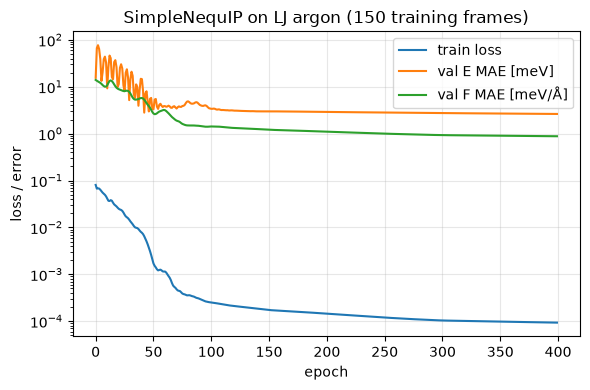

In [6]:
# Visualize the training curves
ax = plot_training_curves(history)
ax.set_title("SimpleNequIP on LJ argon (150 training frames)")
ax.figure.tight_layout()
plt.show()

力奇偶校验图将预测力与参考力进行对比

<details><summary>English</summary>

The force parity plot compares predicted forces against reference forces

</details>

validation energy MAE:   2.63 meV  (0.33 meV/atom)
validation force  MAE:   0.88 meV/Å  (force RMS in data: 32 meV/Å)


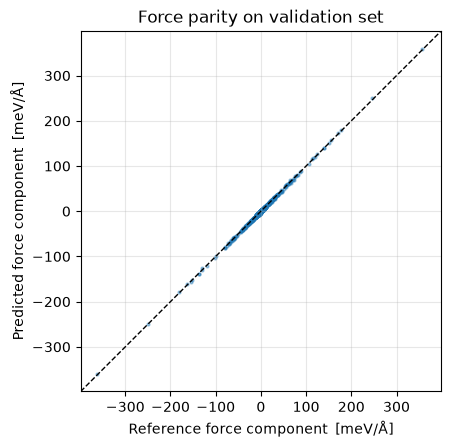

In [7]:
# Set the model to evaluation mode
model.eval()

# Compute the predicted energies and forces for the validation data using the
# trained model
E_hv, F_hv = energy_and_forces(model, pos_va.clone(), edges_va, batch=batch_va)

# Compute the mean absolute error (MAE) for energy and force predictions on the
# validation set
mae_E = (E_hv - E_va).abs().mean().item()
mae_F = (F_hv - F_va).abs().mean().item()

# Print the validation energy and force MAE, scaled to meV and meV/Å
# respectively, along with the per-atom energy MAE
print(f"validation energy MAE: {1000 * mae_E:6.2f} meV  ({1000 * mae_E / n_atoms:.2f} meV/atom)")
print(f"validation force  MAE: {1000 * mae_F:6.2f} meV/Å  "
      f"(force RMS in data: {1000 * F_va.pow(2).mean().sqrt():.0f} meV/Å)")

# Create a force parity plot to visualize the agreement between predicted and
# reference forces
fig, ax = plt.subplots(figsize=(4.6, 4.6))
f_ref = F_va.cpu().numpy().ravel() * 1000
f_pred = F_hv.detach().cpu().numpy().ravel() * 1000
ax.scatter(f_ref, f_pred, s=4, alpha=0.4)
lim = np.abs(f_ref).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Reference force component  [meV/Å]")
ax.set_ylabel("Predicted force component  [meV/Å]")
ax.set_title("Force parity on validation set")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### 等变性在训练后依然存在

NequIP 中的对称性是内建于架构的,而不是学出来的。因此,我们期望它不受训练的影响。以 float64 对预训练权重做一次快速重检,即可给出我们所需的验证

<details><summary>English</summary>

### Equivariance survives the training

Symmetry in NequIP is built into the architecture and not learned. So, we expect
that it remains untouched by the training. A quick re-check of the pre-trained
weights in float64 gives us the verification we need

</details>

In [8]:
# Get the trained model in float64 and evaluate it on the reference geometry to
# check that equivariance is preserved after training
model64 = copy.deepcopy(model).cpu().to(torch.float64).eval()

# Compute the energy and forces for the reference geometry using the trained
# model
E0, F0 = energy_and_forces(model64, pos0.clone(), edges0)

# Improper random rotation
g = -o3.rand_matrix(dtype=torch.float64)

# Random translation
t = torch.randn(3, dtype=torch.float64)

# Compute the energy and forces for the transformed geometry using the trained
# model. The positions are transformed by the rotation and translation, and the
# edges are updated accordingly.
Eg, Fg = energy_and_forces(model64, pos0 @ g.T + t, edges0)

# Check that the energy and forces are equivariant under the transformation. The
# energy should be invariant, and the forces should transform according to the
# rotation matrix. The maximum absolute differences are printed to verify this.
print(f"Trained model:  |ΔE| = {(Eg - E0).abs().max():.2e},  "
      f"|ΔF| = {(Fg - F0 @ g.T).abs().max():.2e}   --> equivariance preserved")

Trained model:  |ΔE| = 5.03e-13,  |ΔF| = 5.46e-12   --> equivariance preserved


## 第三场二番战:rMD17 阿司匹林

在第 07b-07c 课中,我们进行了一组对照实验,比较 `SchNet` 与 `SimpleDimeNet` 的性能,先是在 LJ 氩数据集上(距离就足够),然后在阿司匹林 rMD17 数据集上(角度很重要)。`SimpleNequIP` 模型承诺**无需** $O(Nk^2)$ 三元组枚举即可获得角度表达力。

为保持一致,我们沿用第 07c 课的协议:官方 rMD17,划分为(150 训练 / 50 验证帧),$r_\mathrm{cut} = 5$ Å,25 帧的 mini-batch,带余弦退火的 Adam 优化器,训练 600 个 epoch,相同的损失($\rho = 1$),以及相同的能量逐原子均值平移。有一个例外:学习率为 $10^{-2}$ 而不是 $3\times10^{-3}$。

我们还应注意,第 07c 课的超参数是为不变基线调优的,张量积网络在那里训练明显更慢(在相同预算下仅达到 $\approx$ 121 meV/Å 的力 MAE)。每种架构采用了对自身情况有效的学习率,而其他所有旋钮保持一致。此外,阿司匹林数据集给模型带来了一个新要求:三种化学元素(即 H、C、O),而之前只有一种(即 Ar)。元素的 one-hot 编码(`n_species=3`)现在才真正发挥作用,而对氩来说,初始嵌入只是一个常数。

<details><summary>English</summary>

## The rematch, part three: rMD17 aspirin

In Lessons 07b-07c, we conducted a set of controlled experiment, camparing the
performance of `SchNet` against `SimpleDimeNet`, first on LJ argon dataset
(where distances suffice), then on aspirin rMD17 dataset (where angles matter).
The `SimpleNequIP` model promises angular expressiveness **without** the
$O(Nk^2)$ triplet enumeration. 

We reuse Lesson 07c's protocol for consistency: The official rMD17, split into
(150 train / 50 validation frames), $r_\mathrm{cut} = 5$ Å, mini-batches of 25
frames, Adam optimizer with cosine annealing, training for 600 epochs, the same
loss with $\rho = 1$, and the same per-atom mean shift of the energies. There is
one exception: the learning rate is $10^{-2}$ instead of $3\times10^{-3}$.

We should also note that Lesson 07c's hyperparameters were tuned for the
invariant baselines, and the tensor-product network traied visibly slower there
(it reached only $\approx$ 121 meV/Å force MAE using the same budget). Each
architecture adopted a learning rate that worked for its own case while every
other knob remained identical. Nonethless, the aspirin dataset brought a new
requirement for the models: three chemical elements (i.e., H, C, and O) compared
to one (i.e., Ar). The species one-hot encoding (`n_species=3`) now does the
real work, whereas for argon, the initial embedding was only a constant.

</details>

让我们准备阿司匹林数据集并打印一些统计信息

<details><summary>English</summary>

Let's prepare the aspirin dataset and print some statistics about it

</details>

In [9]:
# Lesson 07c's data protocol: official rMD17 split 01, r_cut = 5 Å, per-atom mean shift
train_asp, val_asp, z_asp = load_rmd17("aspirin", n_train=150, n_val=50)

# Species mapping: {1:0, 6:1, 8:2}
species_map = {int(Z): s for s, Z in enumerate(torch.unique(z_asp).tolist())}

# Convert the atomic numbers in z_asp to species indices using the species_map.
# This creates a tensor of species indices corresponding to each atom in the
# aspirin molecule.
species_asp = torch.tensor([species_map[int(Z)] for Z in z_asp])

# Set the number of atoms and the cutoff radius for the aspirin dataset
n_atoms_asp, r_cut_asp = len(z_asp), 5.0

# Compute the per-atom mean energy shift for the aspirin dataset. This is used to
# normalize the energies during training.
eps_bar = np.mean([f["energy"] for f in train_asp]) / n_atoms_asp

# Define a collate function for the aspirin dataset that includes species
# indices and the per-atom mean shift. This function takes a list of frames and
# returns the concatenated positions, edges, species indices, batch vector,
# energies (with mean shift), and forces.
def collate_asp(frame_list, dtype=torch.float32):
    '''collate() plus species indices and the per-atom mean shift, at r_cut = 5 Å.'''
    
    # Concatenate positions, forces, and energies into single tensors
    pos = torch.cat([f["pos"] for f in frame_list]).to(dtype)
    F = torch.cat([f["forces"] for f in frame_list]).to(dtype)
    E = torch.tensor([f["energy"] - len(f["pos"]) * eps_bar for f in frame_list], dtype=dtype)
    
    # Build the edge index, batch vector, and species indices for the
    # disconnected graph
    spec = species_asp.repeat(len(frame_list))
    edges, batch, offset = [], [], 0
    for k, f in enumerate(frame_list):
        edges.append(radius_graph(f["pos"], r_cut_asp) + offset)
        batch.append(torch.full((f["pos"].shape[0],), k, dtype=torch.long))
        offset += f["pos"].shape[0]
    
    # Return the concatenated positions, edges, species indices, batch vector,
    # energies, and forces.
    return pos, torch.cat(edges, dim=1), spec, torch.cat(batch), E, F

# Lesson 07c's training protocol: mini-batches of 25 frames
batches_asp = [tuple(x.to(device) for x in collate_asp(train_asp[i:i + 25]))
               for i in range(0, len(train_asp), 25)]

# Collate the validation frames into a single batch and move it to the device
val_batch_asp = tuple(x.to(device) for x in collate_asp(val_asp))

# Compute the average number of neighbors for the aspirin dataset using the
# radius_graph function. This is used to inform the model about the expected
# number of neighbors during training.
avg_nn_asp = float(np.mean([radius_graph(f["pos"], r_cut_asp).shape[1] / n_atoms_asp
                            for f in train_asp]))

# Print information about the aspirin dataset, including the number of atoms,
# the number of mini-batches, and the average number of neighbors.
print(f"Aspirin: {n_atoms_asp} atoms (H/C/O), {len(batches_asp)} mini-batches of 25 frames, "
      f"avg neighbors {avg_nn_asp:.1f}")

Aspirin: 21 atoms (H/C/O), 6 mini-batches of 25 frames, avg neighbors 14.4


阿司匹林数据集准备好后,我们现在可以在这些数据上训练 SimpleNequIP 模型了。

<details><summary>English</summary>

With the aspirin dataset prepared, we can now proceed to train the SimpleNequIP
model on this data.

</details>

In [10]:
# Set the random seed for reproducibility
torch.manual_seed(0)

# Initialize the SimpleNequIP model
model_asp = SimpleNequIP(r_cut=r_cut_asp, n_species=3,
                         avg_num_neighbors=avg_nn_asp).to(device)

# Initialize the energy shift and scale
# Same initialization recipe as for argon
with torch.no_grad():
    E_flat = torch.cat([b[4] for b in batches_asp])
    F_flat = torch.cat([b[5] for b in batches_asp])
    model_asp.energy_shift.fill_((E_flat / n_atoms_asp).mean().item())
    model_asp.energy_scale.fill_(F_flat.pow(2).mean().sqrt().item())

# Print the number of parameters in the model
print(f"parameters: {sum(p.numel() for p in model_asp.parameters()):,}")

# Set up the optimizer and learning rate scheduler
optimizer = torch.optim.Adam(model_asp.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600)

# Create the training loop
t0 = time.time()
for epoch in range(600):
    
    # Put the model in training mode
    model_asp.train()
    
    # Iterate over the mini-batches of the aspirin dataset
    for pos_b, edges_b, spec_b, batch_b, E_b, F_b in batches_asp:
        
        # Zero the gradients of the optimizer to prevent accumulation from
        # previous steps
        optimizer.zero_grad()
        
        # Compute the predicted energies and forces for the current mini-batch
        # using the model
        E_hat, F_hat = energy_and_forces(model_asp, pos_b.clone(), edges_b,
                                         species=spec_b, batch=batch_b)
        # Lesson 07c's loss with rho = 1
        loss = ((E_hat - E_b) ** 2).mean() + ((F_hat - F_b) ** 2).sum(dim=-1).mean()
        
        # Backpropagate the loss to compute gradients
        loss.backward()
        
        # Update the model parameters
        optimizer.step()
    
    # Update the learning rate according to the scheduler
    scheduler.step()
    
    # Evaluate the model on the validation set every 100 epochs and at the last
    # epoch
    if epoch % 100 == 0 or epoch == 599:
        
        # Put the model in evaluation mode
        model_asp.eval()
        
        # Compute the predicted energies and forces for the validation batch
        # using the trained model
        pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp
        E_hv, F_hv = energy_and_forces(model_asp, pos_v.clone(), edges_v,
                                       species=spec_v, batch=batch_v)
        
        # Print the epoch number, validation energy MAE, validation force MAE, and
        # elapsed time since the start of training
        print(f"epoch {epoch:3d} | val E MAE {1e3 * (E_hv - E_v).abs().mean().item() / n_atoms_asp:6.2f} meV/atom"
              f" | val F MAE {1e3 * (F_hv - F_v).abs().mean().item():7.2f} meV/Å"
              f" | {time.time() - t0:6.1f} s")
        
# Compute the total training time
dt_asp = time.time() - t0

# Print the total training time
print(f"total training time: {dt_asp:.0f} s on {device}")

parameters: 70,794
epoch   0 | val E MAE 115.22 meV/atom | val F MAE  925.34 meV/Å |    1.8 s
epoch 100 | val E MAE   6.71 meV/atom | val F MAE  160.10 meV/Å |   87.9 s
epoch 200 | val E MAE   7.03 meV/atom | val F MAE  112.39 meV/Å |  173.7 s
epoch 300 | val E MAE   4.11 meV/atom | val F MAE   96.04 meV/Å |  258.2 s
epoch 400 | val E MAE   1.65 meV/atom | val F MAE   88.75 meV/Å |  333.9 s
epoch 500 | val E MAE   1.52 meV/atom | val F MAE   85.86 meV/Å |  411.1 s
epoch 599 | val E MAE   1.51 meV/atom | val F MAE   85.29 meV/Å |  486.9 s
total training time: 487 s on cuda


最后一步是用训练好的模型在验证集上预测能量和力,并与竞争模型 SchNet 和 `SimpleDimeNet` 的参考值进行比较。

<details><summary>English</summary>

The last step is to use the trained model to predict energies and forces on the
validation set and compare them against the reference values from competitor
models, SchNet and `SimpleDimeNet`.  

</details>

In [11]:
# Put the model in evaluation mode
model_asp.eval()

# Compute the predicted energies and forces for the validation batch using the
# trained model
pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp
E_hv, F_hv = energy_and_forces(model_asp, pos_v.clone(), edges_v,
                               species=spec_v, batch=batch_v)
e_nequip = 1e3 * (E_hv - E_v).abs().mean().item() / n_atoms_asp
f_nequip = 1e3 * (F_hv - F_v).abs().mean().item()

# Lesson 07c's table, completed with a new third row for the SimpleNequIP model
print(f"{'val MAE, rMD17 aspirin':>24} | {'E [meV/atom]':>13} | {'F [meV/Å]':>10} | {'s/epoch':>8}")
print(f"{'SchNet (07c)':>24} | {2.35:>13.2f} | {128.61:>10.2f} | {0.09:>8.2f}")
print(f"{'SimpleDimeNet (07c)':>24} | {1.99:>13.2f} | {97.20:>10.2f} | {0.11:>8.2f}")
print(f"{'SimpleNequIP':>24} | {e_nequip:>13.2f} | {f_nequip:>10.2f} | {dt_asp / 600:>8.2f}")

# The same architecture on both datasets, each error against its dataset's force
# scale
f_rms_argon = 1e3 * F_va.pow(2).mean().sqrt().item()
f_rms_asp = 1e3 * F_v.pow(2).mean().sqrt().item()
print(f"\n{'SimpleNequIP, forces':>24} | {'MAE [meV/Å]':>11} | {'data RMS':>8} | relative")
print(f"{'LJ argon':>24} | {1e3 * mae_F:>11.2f} | {f_rms_argon:>8.0f} | {1e3 * mae_F / f_rms_argon:8.1%}")
print(f"{'rMD17 aspirin':>24} | {f_nequip:>11.2f} | {f_rms_asp:>8.0f} | {f_nequip / f_rms_asp:8.1%}")

  val MAE, rMD17 aspirin |  E [meV/atom] |  F [meV/Å] |  s/epoch
            SchNet (07c) |          2.35 |     128.61 |     0.09
     SimpleDimeNet (07c) |          1.99 |      97.20 |     0.11
            SimpleNequIP |          1.51 |      85.29 |     0.81

    SimpleNequIP, forces | MAE [meV/Å] | data RMS | relative
                LJ argon |        0.88 |       32 |     2.8%
           rMD17 aspirin |       85.29 |     1248 |     6.8%


### 解读结果

- **NequIP 在课程预算内表现出色:** 仅以元素 one-hot 嵌入作为唯一的架构改动,`SimpleNequIP` 在相同的 150 帧 rMD17 训练预算下,在能量和原子力两项上都是三个基准模型中最好的:1.51 meV/atom 和 85 meV/Å,对比 `SimpleDimeNet` 的 1.99 和 97,以及 SchNet 的 2.35 和 129。$l > 0$ 特征提供了 `SimpleDimeNet` 需要显式三元组才能获得的角度分辨率,而且仅凭成对消息还略胜一筹。

- **构建消息的代价不可小觑:** 以 $\approx$ 0.9 s/epoch 对 SchNet 基线的 $\approx$ 0.1 s,`SimpleNequIP` 是表中训练最慢的模型。对 NequIP,消息数量按 $O(Nk)$ 而非 $O(Nk^2)$ 缩放,但每条消息都携带一个张量积,其成本远高于 SchNet 中的标量滤波器。在 21 个原子时,常数因子占上风,而扩展性论证要在体系非常大时(例如数千原子)才见回报。这一开销正是第 09 课使用 Allegro 模型所针对的场景。

- **同样的机器,更难的问题:** 相对各自数据集的力尺度,误差在 LJ 氩上为 2.8%,在阿司匹林上为 6.8%。两次实验之间模型的任何部分都没有变,只有 `n_species` 和数据管线变了:为成对玩具势构建的架构,仅通过更换数据集就迁移到了 DFT 质量的分子力上。

<details><summary>English</summary>

### Reading the result

- **NequIP performs well within the course budget:** With the species one-hot
  embeddings as the only architectural change, `SimpleNequIP` provides the best
  performance among the three models benchmarked on both energy and atomic
  forces at the same 150-frame rMD17 training budget: 1.51 meV/atom and 85 meV/Å
  against `SimpleDimeNet`'s 1.99 and 97 and SchNet's 2.35 and 129. The $l > 0$
  features deliver the angular resolution that `SimpleDimeNet` captures using
  explicit triplets, and a little more, on pairwise messages alone.

- **The cost of building messages is not trivial:** At $\approx$ 0.9 s/epoch
  against the SchNet's baseline $\approx$ 0.1 s, `SimpleNequIP` is the slowest
  model in the table. For NequIP, the message count scales as $O(Nk)$ rather
  than $O(Nk^2)$, but each message carries a tensor product, which costs far
  more than a scalar filter in SchNet. At 21 atoms, the constant factor win but
  the scaling argument pays off when the system is very large, e.g., at
  thousands of atoms. This cost is exactly the regime Lesson 09 chases using
  the Allegro model.

- **Same machinery, a more difficult problem:** Relative to each dataset's force
  scale, the error is 2.8% on LJ argon and 6.8% on aspirin. Nothing about the
  model changed between the two experiments except `n_species` and the data
  pipeline: the architecture built for a pairwise toy potential moved to
  DFT-quality molecular forces by swapping the dataset.

</details>

## 为第 11 课和第 13a 课导出模型

在第 11 课中,我们把预训练的 `SimpleNequIP` 模型封装为 ASE 计算器并用它运行分子动力学。我们需要 `notebooks/artifacts/` 中的两个文件:

1. `nequip_model.py`,模型源码模块,已由第 08b 课写好,以及
2. `nequip_lj_argon.pt`,训练好的 `state_dict` 模型工件,加上超参数字典,在下面写出。

我们为第 11 课导出**氩**模型,因为它要将学到的动力学与生成数据的精确 Lennard-Jones 势进行比较,而这只对玩具体系可行。我们还把**阿司匹林**模型导出为 `nequip_aspirin.pt`,[第 13a 课](13a_geometric_interpretability.ipynb)将打开它,追问它的特征究竟代表什么。

<details><summary>English</summary>

## Exporting the models for Lessons 11 and 13a

In Lesson 11, we wrap the pre-trained `SimpleNequIP` model as an ASE calculator
and run molecular dynamics with it. We need two files in `notebooks/artifacts/`:

1. `nequip_model.py`, the model source module, already written by Lesson 08b,
   and
2. `nequip_lj_argon.pt`, the trained `state_dict` model artifact, plus the
   hyperparameter dict, written below.

We export the **argon** model for Lesson 11 because it compares the learned
dynamics against the exact Lennard-Jones potential that generated the data,
which is only possible for the toy system. We also export the **aspirin** model
as `nequip_aspirin.pt`, which [Lesson 13a](13a_geometric_interpretability.ipynb) opens up to
ask what its features actually represent.

</details>

In [12]:
# Save the trained model and its hyperparameters to a checkpoint file in the
# artifacts directory. The checkpoint includes the model's state_dict,
# hyperparameters, and additional information about the dataset and validation
# errors.
art_dir = pathlib.Path("artifacts")
art_dir.mkdir(exist_ok=True)
checkpoint = {
    "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
    "hparams": model.hparams,
    "info": {"dataset": "make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)",
             "val_energy_mae_eV": mae_E, "val_force_mae_eV_per_A": mae_F,
             "units": "eV, Å", "source": "08c_nequip_training.ipynb"},
}
torch.save(checkpoint, art_dir / "nequip_lj_argon.pt")
print(f"saved {art_dir / 'nequip_lj_argon.pt'} "
      f"({(art_dir / 'nequip_lj_argon.pt').stat().st_size / 1024:.0f} kB)")

saved artifacts/nequip_lj_argon.pt (315 kB)


In [13]:
# The aspirin model, for Lesson 13a's feature analysis. The species map is part of
# the artifact: without it, the one-hot embedding indices are meaningless.
checkpoint_asp = {
    "state_dict": {k: v.cpu() for k, v in model_asp.state_dict().items()},
    "hparams": model_asp.hparams,
    "info": {"dataset": "rMD17 aspirin, official split 01 (150 train / 50 val)",
             "species_map": species_map, "z": z_asp.tolist(),
             "val_energy_mae_meV_per_atom": e_nequip, "val_force_mae_meV_per_A": f_nequip,
             "units": "eV, Å", "source": "08c_nequip_training.ipynb"},
}
torch.save(checkpoint_asp, art_dir / "nequip_aspirin.pt")
print(f"saved {art_dir / 'nequip_aspirin.pt'} "
      f"({(art_dir / 'nequip_aspirin.pt').stat().st_size / 1024:.0f} kB)")

saved artifacts/nequip_aspirin.pt (316 kB)


### 往返校验

与第 08b 课类似,当我们导出一个模型工件后,我们会从包含超参数和权重的 checkpoint 重新构建它。这样做是为了确保加载的模型工件能够精确复现训练模型的预测,而不依赖特定 notebook 的状态。

<details><summary>English</summary>

### Round-trip check

Similar to Lesson 08b, when we export a model artifact, we rebuild it again from
its checkpoint which includes hyperparameters plus weights. Doing so, we want to
make sure the loaded model artifact can reproduce the trained model's
predictions exactly, with no reference to a specific notebook state.

</details>

In [14]:
# Reload the model from the checkpoint
ckpt = torch.load(art_dir / "nequip_lj_argon.pt", weights_only=True)

# Recreate the model architecture using the hyperparameters stored in the
# checkpoint
model_reloaded = SimpleNequIP(**ckpt["hparams"])

# Load the state_dict from the checkpoint into the reloaded model
model_reloaded.load_state_dict(ckpt["state_dict"])

# Set the reloaded model to evaluation mode
model_reloaded.eval()


# Create a CPU copy of the trained model for comparison with the reloaded model. 
model_cpu = copy.deepcopy(model).cpu().eval()

# Get the positions of the first validation frame and convert them to float32
# for the radius_graph function. 
pos_check = val_frames[0]["pos"].to(torch.float32)

# Compute the edges for the first validation frame using the radius_graph
# function with the cutoff radius.
edges_check = radius_graph(pos_check, r_cut)

# Compute the energy and forces for the first validation frame using both the
# CPU copy of the trained model and the reloaded model.
E_a, F_a = energy_and_forces(model_cpu, pos_check.clone(), edges_check)
E_b, F_b = energy_and_forces(model_reloaded, pos_check.clone(), edges_check)

# Check that the energies and forces from both models are close to each other
# within a tolerance of 1e-7. This ensures that the reloaded model reproduces
# the predictions of the original trained model.
assert torch.allclose(E_a, E_b, atol=1e-7) and torch.allclose(F_a, F_b, atol=1e-7)
print(f"The reloaded model reproduces predictions:   (E = {E_a.item():+.5f} eV vs reference "
      f"{val_frames[0]['energy']:+.5f} eV)")

The reloaded model reproduces predictions:   (E = -0.08226 eV vs reference -0.08269 eV)


## 总结

在本课中,我们学到了:

- 如何用能量与力损失的加权组合构成的联合损失,在 150 帧 LJ 氩数据集上训练 `SimpleNequIP`。验证力 MAE 落在 meV/Å 的一小部分:约为数据中力尺度的 2.8%,GPU 时间不到两分钟。

- **等变性挺过了训练:** 理应如此!我们验证了模型在第 08b 课能在随机权重下通过对称性检验,在这里能在训练后的权重下以同样的 $10^{-13}$ 等变容差通过检验。

- **NequIP 在阿司匹林 rMD17 基准上表现出色:** 在第 07c 课的协议下(学习率除外),`SimpleNequIP` 达到 1.51 meV/atom 和 85 meV/Å 的验证 MAE:领先于 SchNet(2.35, 128.6)和 `SimpleDimeNet`(1.99, 97.2),且仅用成对消息,代价是表中最慢的吞吐量。

**下一课:** [第 09a 课](09a_allegro_theory.ipynb)聚焦于 Allegro,它无需消息传递即可实现等变性:这一特性在大规模场景中变得重要。

<details><summary>English</summary>

## Summary

In this lesson, we have learned:

- How to train `SimpleNequIP` on 150 frames of LJ argon dataset with a joint
  loss of weighted combination of energy and force losses. The validation force
  MAE landed at a fraction of a meV/Å: about 2.8% of the force scale in the data
  in well under two minutes of GPU time.

- **Equivariance survived the training:** As it must! We have checked that the
  model can pass the symmetry test on random weights in Lesson 08b and on
  trained weights here with the same $10^{-13}$ tolerance for equivariance.

- **NequIP performs well on the aspirin rMD17 benchmark:** Under Lesson 07c's
  protocol (learning rate aside), `SimpleNequIP` reached 1.51 meV/atom and 85
  meV/Å validation MAE: ahead of both SchNet (2.35, 128.6) and `SimpleDimeNet`
  (1.99, 97.2), with pairwise messages only, at the price of the slowest
  throughput in the table.

**Next**: [Lesson 09a](09a_allegro_theory.ipynb) focuses on Allegro, which
achieves equivariance without message passing: A feature that becomes important
at large scales.

</details>

## 练习

**1. 不变基线(难度:🌶️):** 重新训练在 LJ 氩数据集上训练过的 `SimpleNequIP` 模型,这次用 `l_max=0`,其他所有设置和 epoch 预算保持不变。将所得模型的验证力 MAE 与正文中的运行结果比较。然后解释:为什么在 LJ 氩数据集上两个模型的差距很小,而在阿司匹林 rMD17 这类分子的 DFT 数据上差距应当拉大?

<details><summary>解答</summary>

使用 `l_max=0` 会把滤波器截断为 `1x0e`。于是张量积只能产生标量。`irreps_hidden` 的 `1o`/`1e` 通道仍会被分配但恒为零,卷积退化为 SchNet 式的由 $R(r)$ 加权的标量消息。(不要试图通过设置 `mul1=mul2=0` 删除这些通道:一个没有东西可操作的 `Gate` 会抛出 `ValueError`)。

LJ 氩数据集上差距很小,因为能量只依赖于原子对距离,标量消息可以精确捕获。仅靠距离不足以刻画分子中的 DFT 相互作用:键角、二面角和极化需要同时关联多个邻居的**方向**,这正是 $l \ge 1$ 特征所能发挥的作用(第 08a 课)。不变网络必须间接地重建这种空间信息,即通过若干层中重叠的距离模式。对阿司匹林数据集,不变基线受限于无法在单层内解析角度关联,它与使用 $l \ge 1$ 特征直接解析角度关联的等变模型之间的差距随之拉大。
</details>

**2. 学到的 Bessel 根(难度:🌶️🌶️):** 径向基从 Bessel 根 $b\pi$($b = 1, \dots, 8$)出发,但 `basis.b_pi` 是可训练的。训练后打印 `model.basis.b_pi / torch.pi`,看每个频率偏离其初始整数值多远。然后像第 08b 课绘制初始化基那样,把训练后的基画在 $r \in [3, 6]$ Å 上,并说出训练锐化了哪个距离范围。注意氩原子对聚集在 LJ 极小值 $2^{1/6}\sigma \approx 3.8$ Å 附近。

<details><summary>解答</summary>

```python
from artifacts.nequip_model import BesselBasis

# Calculate the ratio of the learned Bessel roots to pi
ratio = (model.basis.b_pi / torch.pi).detach().cpu()

# Calculate the percentage shift of each learned Bessel root from its initial integer value
b = torch.arange(1, len(ratio) + 1)
shift = 100 * (ratio - b) / b

# Print the results
print("b_pi / pi :", " ".join(f"{v:6.3f}" for v in ratio))
print("shift [%] :", " ".join(f"{v:+6.1f}" for v in shift))

# Initialize a fresh Bessel basis for comparison
fresh = BesselBasis(r_cut, model.basis.n_basis)

# Create a range of r values for plotting
r = torch.linspace(0.5, r_cut, 400)

# Compute the trained and initial basis functions
with torch.no_grad():
    B_trained, B_initial = model.basis(r), fresh(r)

# Plot the trained and initial basis functions
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
for k, color in ((0, "tab:blue"), (1, "tab:red")):
    axes[0].plot(r, B_initial[:, k], color=color, ls="--", lw=1.2, label=f"$b={k+1}$ initial")
    axes[0].plot(r, B_trained[:, k], color=color, lw=1.8, label=f"$b={k+1}$ trained")

# The LJ minimum
axes[0].axvline(2 ** (1 / 6) * 3.4, color="k", ls=":", lw=1.2)
axes[0].set_xlabel("pair distance $r$  [Å]")
axes[0].set_ylabel("$B_b(r)$")
axes[0].set_title("the two lowest frequencies")
axes[0].legend(fontsize=7)
axes[1].bar(b, shift, color="tab:blue")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("basis function $b$")
axes[1].set_ylabel(r"shift from $b\pi$  [%]")
axes[1].set_title("Where training moved the frequencies")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
```

```
b_pi / pi :  1.059  1.931  3.017  3.940  4.994  5.981  7.014  8.075
shift [%] :   +5.9   -3.5   +0.6   -1.5   -0.1   -0.3   +0.2   +0.9
```

**基几乎不动。** 每个比值都保持在初始整数值的 6% 以内,训练后的曲线与初始曲线至多相差 0.013,相对 0.35 的峰值约为 3%。基于物理动机的初始化已经接近模型想要达到的目标,这正是选择它而非通用 $r$ 的 MLP 的论据。

大部分移动集中在两个最低频率上($b = 1$ 为 $+5.9\%$,$b = 2$ 为 $-3.5\%$,而 $b \geq 3$ 时 $\leq 1.5\%$;后者恰是承载第一邻居壳层结构的那些)。$b = 2$ 的节点(函数取零处)从 3.01 Å 向外移到 3.12 Å,朝向阱极小值 $2^{1/6}\sigma \approx 3.8$ Å,而 $b = 1$ 在 5.67 Å 处获得一个节点。更快的函数在数据之外的区间振荡,未被触碰。

</details>

**3. 学习率对 NequIP 的性能有多重要?(难度:🌶️🌶️🌶️):** 正文中的阿司匹林运行恰好在第 07c 课的基础上改了一个旋钮:学习率从 $3\times10^{-3}$ 改为 $10^{-2}$。在其余一切保持固定的条件下,以 $3\times10^{-3}$ 和 $5\times10^{-3}$ 的学习率重复训练实验,并把三条验证力 MAE 曲线画在同一坐标轴上。较慢的模型是收敛得晚,还是收敛到了更差的解?回答之前,先看看 `CosineAnnealingLR(T_max=600)` 在 epoch 600 附近对三条曲线都做了什么。然后,设计一个能真正解决这个问题的实验。

<details><summary>解答</summary>

```python
def run_at(lr, n_epochs=600):
    """The aspirin run of the main text, with the learning rate as a knob."""

    # Set the random seed for reproducibility
    torch.manual_seed(0)

    # Initialize the model and move it to the appropriate device
    m = SimpleNequIP(r_cut=r_cut_asp, n_species=3, avg_num_neighbors=avg_nn_asp).to(device)

    # Initialize the energy shift and scale based on the training batches
    with torch.no_grad():
        E_flat = torch.cat([b[4] for b in batches_asp])
        F_flat = torch.cat([b[5] for b in batches_asp])
        m.energy_shift.fill_((E_flat / n_atoms_asp).mean().item())
        m.energy_scale.fill_(F_flat.pow(2).mean().sqrt().item())

    # Set up the optimizer and learning rate scheduler
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # Unpack the validation batch for later use
    pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp

    curve = []
    for epoch in range(n_epochs):
        m.train()
        for pos_b, edges_b, spec_b, batch_b, E_b, F_b in batches_asp:
            opt.zero_grad()
            E_hat, F_hat = energy_and_forces(m, pos_b.clone(), edges_b,
                                             species=spec_b, batch=batch_b)
            loss = ((E_hat - E_b) ** 2).mean() + ((F_hat - F_b) ** 2).sum(dim=-1).mean()
            loss.backward()
            opt.step()
        sched.step()

        m.eval()                                          # validate every epoch, for the curve
        _, F_hv = energy_and_forces(m, pos_v.clone(), edges_v, species=spec_v, batch=batch_v)
        curve.append(1e3 * (F_hv - F_v).abs().mean().item())
    return curve

# About 24 min on an A100 GPU
curves = {lr: run_at(lr) for lr in (1e-2, 5e-3, 3e-3)}

# Plot the three curves on one axis
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for lr, curve in curves.items():
    ax.plot(curve, lw=1.5, label=f"lr = {lr:.0e}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("validation force MAE  [meV/Å]")
ax.set_title("SimpleNequIP on rMD17 aspirin, one knob changed")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# Print the final validation force MAE and the gain over the last 50 epochs
for lr, curve in curves.items():
    print(f"lr {lr:.0e}: final {curve[-1]:7.2f} meV/Å"
          f" | gain over the last 50 epochs {curve[-50] - curve[-1]:.2f}")
```

```
lr 1e-02: final   85.28 meV/Å | gain over the last 50 epochs 0.07
lr 5e-03: final  104.51 meV/Å | gain over the last 50 epochs 0.07
lr 3e-03: final  121.23 meV/Å | gain over the last 50 epochs 0.07
```

排序在每个 epoch 都成立,而不只是最后一个:epoch 200 时为 112 / 134 / 150 meV/Å,epoch 400 时为 89 / 108 / 125。$10^{-2}$ 的运行精确复现了正文的 85.28 meV/Å。

**但平坦的尾部并不表明收敛:** 每条运行在其最后 50 个 epoch 内都只提升 0.07 meV/Å,而最后 20 个 epoch 内毫无提升。这是因为 `CosineAnnealingLR(T_max=600)` 按调度把步长驱赶到零,使每条运行在 epoch 600 时按构造变平。所以尾部无法区分两个假设。要解决这个问题,请给较慢的运行它自己的调度所隐含的预算:

```python
# Run for another ~15 min
long = run_at(3e-3, n_epochs=1200)
print(f"lr 3e-03 at 1200 epochs: {long[-1]:.2f} meV/Å"
      f"  (600 epochs gave {curves[3e-3][-1]:.2f}; epoch 599 of this run: {long[599]:.2f})")
```

```
lr 3e-03 at 1200 epochs: 95.53 meV/Å  (600 epochs gave 121.23; epoch 599 of this run: 106.66)
```

预算翻倍使 $3\times10^{-3}$ 从 121.23 降到 95.53 meV/Å,弥合了 35.9 meV/Å 差距的 71%:主要是"收敛得晚",尽管以两倍代价仍残留 10.2 meV/Å。

在 epoch 599,较长的运行位于 106.66 meV/Å,而较短的运行在相同 epoch、相同学习率下已被退火到 121.23:调度把模型冻结在它尚未真正到达的点上。为某一模型族调优的学习率和调度,可能在固定预算下拖累另一个模型族,而且这种拖累与容量不足无法区分,除非你专门去找——这正是本课标注其偏离第 07c 课协议的原因。
</details>

<details><summary>English</summary>

## Exercises

**1. Invariant baseline (Difficulty: 🌶️):** Retrain the `SimpleNequIP` model
which was trained on the LJ argon dataset, this time with `l_max=0`, while
keeping every other setting and epoch budget the same. Compare the resulting
model's validation force MAE against the run in the main text. Then explain: why
is the gap between the two models small on the LJ argon dataset, and why should
it widen on the DFT data for molecules such as those in the aspirin rMD17
dataset?

<details><summary>Solution</summary>

Using the `l_max=0` truncates the filter to `1x0e`. So, the tensor product can
only ever produce scalars. The `1o`/`1e` channels of `irreps_hidden` are still
allocated but stay identically zero, and the convolution collapses to
SchNet-style scalar messages weighted by $R(r)$. (Do not try to delete those
channels by setting `mul1=mul2=0`: a `Gate` with nothing left to operate on
raises a `ValueError`).

The difference gap is small for the LJ argon dataset because the energies depend
only on the pair distances, which scalar messages can capture exactly. Distances
alone are not sufficient to delineate the DFT interactions in molecules: bond
angles, dihedrals and polarization require correlating the **directions** of
several neighbors at once, which is what the $l \ge 1$ features can bring into
play (Lesson 08a). An invariant network must rebuild this spacial information
indirectly, from overlapping distance patterns across several layers. For the
aspirin dataset, the invariant baseline is handicapped by its inability to
resolve the angular correlations in a single layer, and the gap widens between
this basline and an equivariant model that uses the $l \ge 1$ features to
resolve the angular correlations directly.
</details>

**2. Learned Bessel roots (Difficulty: 🌶️🌶️):** The radial basis starts at the
Bessel roots $b\pi$ with $b = 1, \dots, 8$, but `basis.b_pi` is trainable. Print
`model.basis.b_pi / torch.pi` after training and see how far each frequency
moved from its initial integer value. Then plot the trained basis over $r \in
[3, 6]$ Å, as Lesson 08b plots the initialized ones, and say which distance
range the training sharpened. Note that the argon pairs cluster near the LJ
minimum of $2^{1/6}\sigma \approx 3.8$ Å.

<details><summary>Solution</summary>

```python
from artifacts.nequip_model import BesselBasis

# Calculate the ratio of the learned Bessel roots to pi
ratio = (model.basis.b_pi / torch.pi).detach().cpu()

# Calculate the percentage shift of each learned Bessel root from its initial integer value
b = torch.arange(1, len(ratio) + 1)
shift = 100 * (ratio - b) / b

# Print the results
print("b_pi / pi :", " ".join(f"{v:6.3f}" for v in ratio))
print("shift [%] :", " ".join(f"{v:+6.1f}" for v in shift))

# Initialize a fresh Bessel basis for comparison
fresh = BesselBasis(r_cut, model.basis.n_basis)

# Create a range of r values for plotting
r = torch.linspace(0.5, r_cut, 400)

# Compute the trained and initial basis functions
with torch.no_grad():
    B_trained, B_initial = model.basis(r), fresh(r)

# Plot the trained and initial basis functions
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
for k, color in ((0, "tab:blue"), (1, "tab:red")):
    axes[0].plot(r, B_initial[:, k], color=color, ls="--", lw=1.2, label=f"$b={k+1}$ initial")
    axes[0].plot(r, B_trained[:, k], color=color, lw=1.8, label=f"$b={k+1}$ trained")

# The LJ minimum
axes[0].axvline(2 ** (1 / 6) * 3.4, color="k", ls=":", lw=1.2)
axes[0].set_xlabel("pair distance $r$  [Å]")
axes[0].set_ylabel("$B_b(r)$")
axes[0].set_title("the two lowest frequencies")
axes[0].legend(fontsize=7)
axes[1].bar(b, shift, color="tab:blue")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("basis function $b$")
axes[1].set_ylabel(r"shift from $b\pi$  [%]")
axes[1].set_title("Where training moved the frequencies")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
```

```
b_pi / pi :  1.059  1.931  3.017  3.940  4.994  5.981  7.014  8.075
shift [%] :   +5.9   -3.5   +0.6   -1.5   -0.1   -0.3   +0.2   +0.9
```

**The basis barely moves.** Every ratio stays within 6% of its initial
integervalue, and the trained and initialized curves differ by at most 0.013
against a 0.35 peak which is about 3%. The physics-motivated initialization is
already close to what the model wants to achieve, which is the argument for
choosing it over a generic MLP of $r$.

Most of the movement focus around the two lowest frequencies ($+5.9\%$ for $b =
1$, $-3.5\%$ for $b = 2$, against $\leq 1.5\%$ for $b \geq 3$; the latter being
the ones with first-neighbor-shell structure). The node (where the value of the
function is zero) of $b = 2$ moves outward from 3.01 Å to 3.12 Å, toward the
well minimum at $2^{1/6}\sigma \approx 3.8$ Å, and $b = 1$ gains a node at 5.67
Å. Faster functions oscillate beyond anything in the data and are untouched.

</details>

**3. How much does the learning rate matter for NequIP's performance?
(Difficulty: 🌶️🌶️🌶️):** The aspirin run in the text changes exactly one knob
from Lesson 07c: the learning rate, which changes from $3\times10^{-3}$ to
$10^{-2}$. Repeat the training experiment with a learning rate of
$3\times10^{-3}$ and $5\times10^{-3}$ with everything else held fixed, and plot
the three validation force-MAE curves on one axis. Is the slower model
converging late, or converging to a worse solution? Before you answer, look at
what `CosineAnnealingLR(T_max=600)` is doing to all three curves near epoch 600.
Then, design an experiment that actually settles the question.

<details><summary>Solution</summary>

```python
def run_at(lr, n_epochs=600):
    """The aspirin run of the main text, with the learning rate as a knob."""

    # Set the random seed for reproducibility
    torch.manual_seed(0)

    # Initialize the model and move it to the appropriate device
    m = SimpleNequIP(r_cut=r_cut_asp, n_species=3, avg_num_neighbors=avg_nn_asp).to(device)

    # Initialize the energy shift and scale based on the training batches
    with torch.no_grad():
        E_flat = torch.cat([b[4] for b in batches_asp])
        F_flat = torch.cat([b[5] for b in batches_asp])
        m.energy_shift.fill_((E_flat / n_atoms_asp).mean().item())
        m.energy_scale.fill_(F_flat.pow(2).mean().sqrt().item())

    # Set up the optimizer and learning rate scheduler
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # Unpack the validation batch for later use
    pos_v, edges_v, spec_v, batch_v, E_v, F_v = val_batch_asp

    curve = []
    for epoch in range(n_epochs):
        m.train()
        for pos_b, edges_b, spec_b, batch_b, E_b, F_b in batches_asp:
            opt.zero_grad()
            E_hat, F_hat = energy_and_forces(m, pos_b.clone(), edges_b,
                                             species=spec_b, batch=batch_b)
            loss = ((E_hat - E_b) ** 2).mean() + ((F_hat - F_b) ** 2).sum(dim=-1).mean()
            loss.backward()
            opt.step()
        sched.step()

        m.eval()                                          # validate every epoch, for the curve
        _, F_hv = energy_and_forces(m, pos_v.clone(), edges_v, species=spec_v, batch=batch_v)
        curve.append(1e3 * (F_hv - F_v).abs().mean().item())
    return curve

# About 24 min on an A100 GPU
curves = {lr: run_at(lr) for lr in (1e-2, 5e-3, 3e-3)}

# Plot the three curves on one axis
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for lr, curve in curves.items():
    ax.plot(curve, lw=1.5, label=f"lr = {lr:.0e}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("validation force MAE  [meV/Å]")
ax.set_title("SimpleNequIP on rMD17 aspirin, one knob changed")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# Print the final validation force MAE and the gain over the last 50 epochs
for lr, curve in curves.items():
    print(f"lr {lr:.0e}: final {curve[-1]:7.2f} meV/Å"
          f" | gain over the last 50 epochs {curve[-50] - curve[-1]:.2f}")
```

```
lr 1e-02: final   85.28 meV/Å | gain over the last 50 epochs 0.07
lr 5e-03: final  104.51 meV/Å | gain over the last 50 epochs 0.07
lr 3e-03: final  121.23 meV/Å | gain over the last 50 epochs 0.07
```

The ordering holds at every epoch, not just the last one: 112 / 134 / 150 meV/Å
at epoch 200, and 89 / 108 / 125 at epoch 400. The $10^{-2}$ run reproduces the
main text's 85.28 meV/Å exactly.

**But the flat tails do not indicate convergence:** Each run gains 0.07 meV/Å
over its last 50 epochs and nothing at all over their last 20. This is because
the `CosineAnnealingLR(T_max=600)` drives the step size to zero on a schedule so
that every run becomes flat at epoch 600 by construction. So, the tails cannot
separate the two hypotheses. To address this issue, give the slower run the
budget its own schedule implies instead:

```python
# Run for another ~15 min
long = run_at(3e-3, n_epochs=1200)
print(f"lr 3e-03 at 1200 epochs: {long[-1]:.2f} meV/Å"
      f"  (600 epochs gave {curves[3e-3][-1]:.2f}; epoch 599 of this run: {long[599]:.2f})")
```

```
lr 3e-03 at 1200 epochs: 95.53 meV/Å  (600 epochs gave 121.23; epoch 599 of this run: 106.66)
```

Doubling the budget takes $3\times10^{-3}$ from 121.23 to 95.53 meV/Å, closing
71% of the 35.9 meV/Å gap: mostly "converging late", though 10.2 meV/Å survives
at twice the cost.

At epoch 599, the longer run sits at 106.66 meV/Å while the shorter run, at the
same epoch and the same learning rate, had been annealed down to 121.23: the
schedule froze the model at a point it had not finished reaching. A learning
rate and schedule tuned for one model family can handicap another at a fixed
budget, and the handicap is indistinguishable from lower capacity unless you go
looking, which is why this lesson flags its deviation from Lesson 07c's
protocol.
</details>

</details>

## 参考文献

- [Batzner et al., *NequIP: E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials* Nat. Commun. 13 2453 (2022)](https://doi.org/10.1038/s41467-022-29939-5)

<details><summary>English</summary>

## Reference

- [Batzner et al., *NequIP: E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials* Nat. Commun. 13 2453 (2022)](https://doi.org/10.1038/s41467-022-29939-5)

</details>